In [ ]:
import pandas as pd

In [ ]:
column_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]


In [ ]:
df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=column_names
)

In [ ]:
# --------------------------------------------
# Display the first five samples
# --------------------------------------------
print("First Five Samples:\n")
print(df.head())


First Five Samples:

   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [ ]:
# --------------------------------------------
# Determine dataset dimensions
# --------------------------------------------
print("\nDataset Dimensions:")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


Dataset Dimensions:
Rows    : 1372
Columns : 5


In [ ]:
# --------------------------------------------
# Display dataset information
# --------------------------------------------
print("\nDataset Information:\n")
print(df.info())



Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None


In [ ]:
# --------------------------------------------
# Identify missing values
# --------------------------------------------
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [ ]:

# --------------------------------------------
# Display descriptive statistics
# --------------------------------------------
print("\nDescriptive Statistics:\n")
print(df.describe())


Descriptive Statistics:

          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


In [ ]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
sns.set(style="whitegrid")

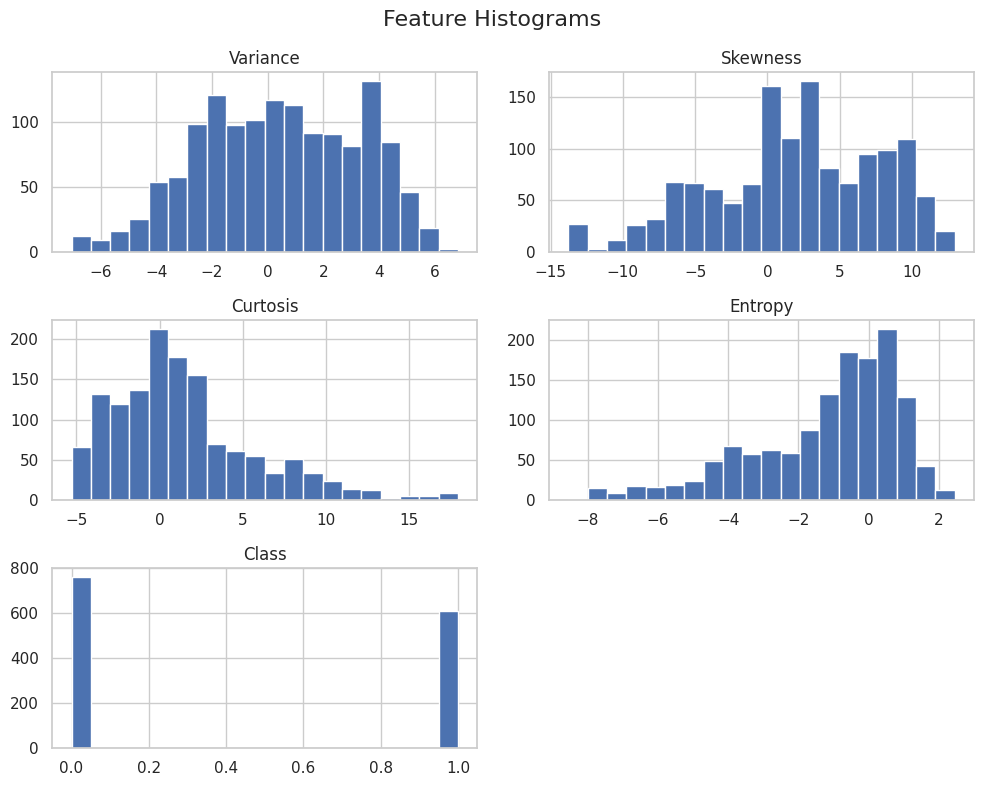

In [ ]:
df.hist(figsize=(10, 8), bins=20)
plt.suptitle("Feature Histograms", fontsize=16)
plt.tight_layout()
plt.savefig('feature_histograms.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

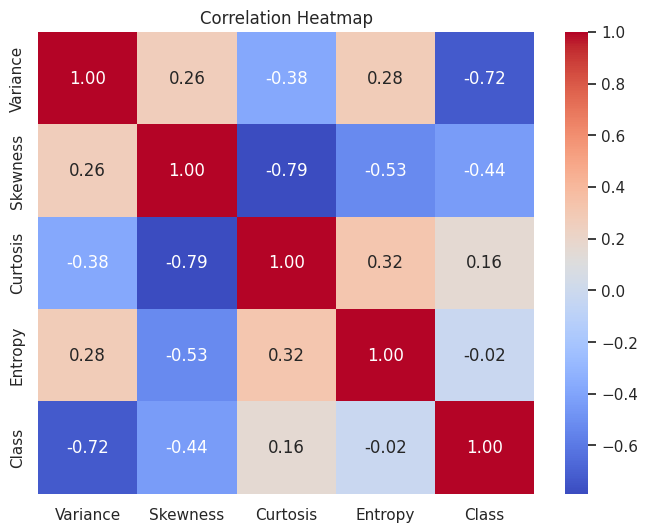

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig('correlation_heatmap.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

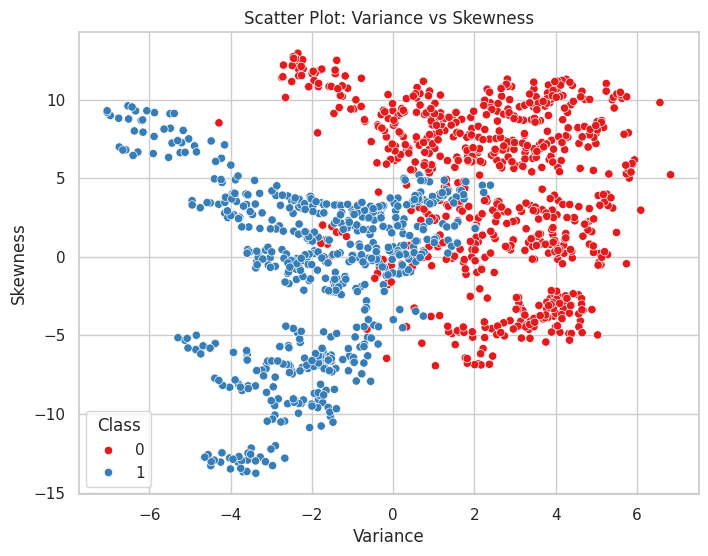

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Variance", y="Skewness", hue="Class", palette="Set1")
plt.title("Scatter Plot: Variance vs Skewness")
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.legend(title="Class")
plt.savefig('scatter_plot.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

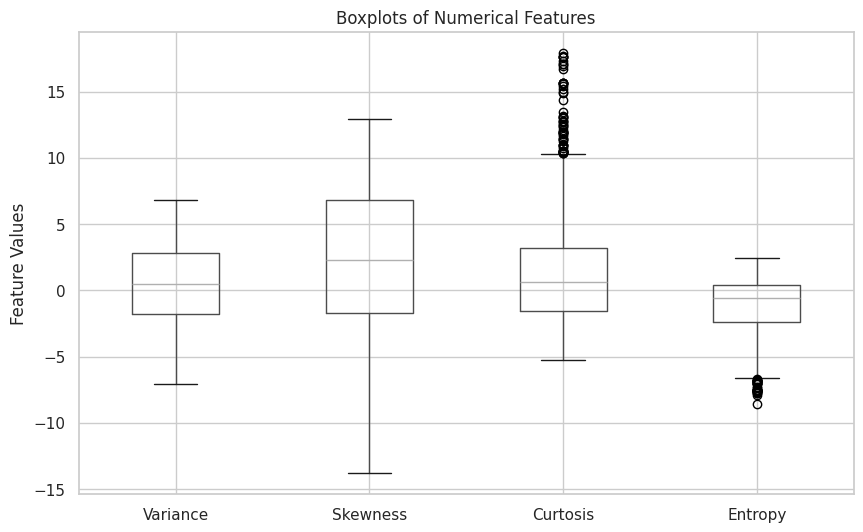

In [ ]:
# --------------------------------------------
# 4. Boxplots
# --------------------------------------------
plt.figure(figsize=(10, 6))

df.drop("Class", axis=1).boxplot()

plt.title("Boxplots of Numerical Features")
plt.ylabel("Feature Values")
plt.show()

In [ ]:
# ============================================
# Task 3: Data Preprocessing
# ============================================


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


In [ ]:
# --------------------------------------------
# Separate features and target
# --------------------------------------------
X = df.drop("Class", axis=1)
y = df["Class"]

# --------------------------------------------
# Normalize numerical features
# --------------------------------------------
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:

# --------------------------------------------
# Split into Training (80%) and Testing (20%)
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)


In [ ]:
# --------------------------------------------
# Display dataset sizes
# --------------------------------------------
print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)

print("\nTraining Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Feature Shape : (1097, 4)
Testing Feature Shape  : (275, 4)

Training Labels Shape : (1097,)
Testing Labels Shape  : (275,)


In [ ]:
# ============================================
# Task 4: Single Layer Perceptron Implementation
# ============================================

import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate

        # Weights and bias will be initialized later
        self.weights = None
        self.bias = None
    # --------------------------------------------
    # Weight and Bias Initialization
    # --------------------------------------------
    def initialize_parameters(self, n_features):

        # Initialize weights with zeros
        self.weights = np.zeros(n_features)

        # Initialize bias with zero
        self.bias = 0
    def step_activation(self, z):

        if z >= 0:
            return 1
        else:
            return 0
    # --------------------------------------------
    # Forward Propagation
    # --------------------------------------------
    def predict(self, X):

        predictions = []

        for x in X:

            # Weighted sum
            z = np.dot(x, self.weights) + self.bias

            # Apply Step Activation
            y_pred = self.step_activation(z)

            predictions.append(y_pred)

        return np.array(predictions)

    # --------------------------------------------
    # Perceptron Learning Rule
    # --------------------------------------------
    def update_weights(self, x, target):

        # Current prediction
        prediction = self.predict([x])[0]

        # Calculate error
        error = target - prediction

        # Update weights
        self.weights = self.weights + self.learning_rate * error * x

        # Update bias
        self.bias = self.bias + self.learning_rate * error

        return error

In [ ]:
# --------------------------------------------
# Model Training
# --------------------------------------------
def fit(self, X_train, y_train, max_epochs=50):

    # Initialize weights and bias
    self.initialize_parameters(X_train.shape[1])

    # Store training history
    self.errors_history = []
    self.weights_history = []
    self.bias_history = []

    for epoch in range(max_epochs):

        errors = 0

        for x, target in zip(X_train, y_train):

            prediction = self.predict([x])[0]

            error = target - prediction

            if error != 0:
                errors += 1

            # Perceptron Learning Rule
            self.weights += self.learning_rate * error * x
            self.bias += self.learning_rate * error

        # Store history
        self.errors_history.append(errors)
        self.weights_history.append(self.weights.copy())
        self.bias_history.append(self.bias)

        # Display progress
        print(f"\nEpoch {epoch+1}")
        print(f"Misclassified Samples : {errors}")
        print(f"Weights : {self.weights}")
        print(f"Bias : {self.bias}")

        # Convergence
        if errors == 0:
            print("\nTraining Converged!")
            break

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [ ]:
# ============================================
# Model Evaluation
# ============================================

def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    cm = confusion_matrix(y_test, predictions)

    print("\n========== MODEL EVALUATION ==========")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    return accuracy, precision, recall, f1, cm

In [ ]:
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate
        self.weights = None
        self.bias = None

    # ----------------------------
    # Initialize weights and bias
    # ----------------------------
    def initialize_parameters(self, n_features):
        self.weights = np.zeros(n_features)
        self.bias = 0

    # ----------------------------
    # Step Activation Function
    # ----------------------------
    def step_activation(self, z):
        if z >= 0:
            return 1
        else:
            return 0

    # ----------------------------
    # Forward Propagation
    # ----------------------------
    def predict(self, X):

        predictions = []

        for x in X:

            z = np.dot(x, self.weights) + self.bias

            y_pred = self.step_activation(z)

            predictions.append(y_pred)

        return np.array(predictions)

    # ----------------------------
    # Model Training
    # ----------------------------
    def fit(self, X_train, y_train, max_epochs=50):

        self.initialize_parameters(X_train.shape[1])

        self.errors_history = []
        self.weights_history = []
        self.bias_history = []

        for epoch in range(max_epochs):

            errors = 0

            for x, target in zip(X_train, y_train):

                prediction = self.predict([x])[0]

                error = target - prediction

                if error != 0:
                    errors += 1

                    # Perceptron Learning Rule
                    self.weights += self.learning_rate * error * x
                    self.bias += self.learning_rate * error

            self.errors_history.append(errors)
            self.weights_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(f"\nEpoch {epoch+1}")
            print(f"Misclassified Samples : {errors}")
            print(f"Weights : {self.weights}")
            print(f"Bias : {self.bias}")

            # Convergence
            if errors == 0:
                print("\nModel Converged!")
                break

In [ ]:
perceptron = Perceptron()

print(dir(perceptron))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'bias', 'fit', 'initialize_parameters', 'learning_rate', 'predict', 'step_activation', 'weights']


In [ ]:
learning_rates = [0.001, 0.01, 0.1]

results = []

for lr in learning_rates:

    print("="*60)
    print(f"Training with Learning Rate = {lr}")
    print("="*60)

    perceptron = Perceptron(learning_rate=lr)

    perceptron.fit(X_train, y_train)

    accuracy, precision, recall, f1, cm = evaluate_model(
        perceptron,
        X_test,
        y_test
    )

    results.append({
        "Learning Rate": lr,
        "Epochs": len(perceptron.errors_history),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Weights": perceptron.weights.copy(),
        "Bias": perceptron.bias
    })

Training with Learning Rate = 0.001

Epoch 1
Misclassified Samples : 166
Weights : [-0.00682741 -0.00386685 -0.0053191   0.00152935]
Bias : 0.008

Epoch 2
Misclassified Samples : 88
Weights : [-0.00831161 -0.00614632 -0.00768784  0.00116242]
Bias : 0.010000000000000002

Epoch 3
Misclassified Samples : 57
Weights : [-0.00873157 -0.00656554 -0.00959305  0.001506  ]
Bias : 0.011000000000000003

Epoch 4
Misclassified Samples : 51
Weights : [-0.00953857 -0.00797431 -0.0092854   0.00101702]
Bias : 0.012000000000000004

Epoch 5
Misclassified Samples : 47
Weights : [-0.00977834 -0.00856403 -0.01002551  0.00057811]
Bias : 0.013000000000000005

Epoch 6
Misclassified Samples : 45
Weights : [-0.01058116 -0.00886184 -0.01014938  0.00043303]
Bias : 0.014000000000000005

Epoch 7
Misclassified Samples : 48
Weights : [-0.01116004 -0.00991264 -0.01083002  0.00090912]
Bias : 0.014000000000000005

Epoch 8
Misclassified Samples : 32
Weights : [-0.0117965  -0.01012441 -0.011616    0.00099908]
Bias : 0.01400

In [ ]:
import pandas as pd

summary = pd.DataFrame(results)

print("\nTraining Summary")
print(summary)


Training Summary
   Learning Rate  Epochs  Accuracy  Precision    Recall  F1-score  \
0          0.001      50  0.989091        1.0  0.976378  0.988048   
1          0.010      50  0.989091        1.0  0.976378  0.988048   
2          0.100      50  0.989091        1.0  0.976378  0.988048   

                                             Weights   Bias  
0  [-0.018091630652849612, -0.017964979101729887,...  0.024  
1  [-0.1809163065284943, -0.17964979101729658, -0...  0.240  
2  [-1.8091630652849688, -1.7964979101729937, -2....  2.400  


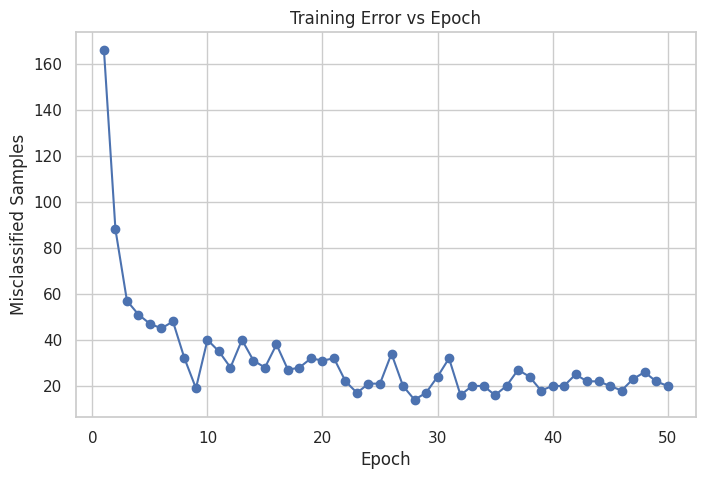

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(perceptron.errors_history)+1), perceptron.errors_history, marker='o')
plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.grid(True)
plt.savefig('training_error_vs_epoch.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

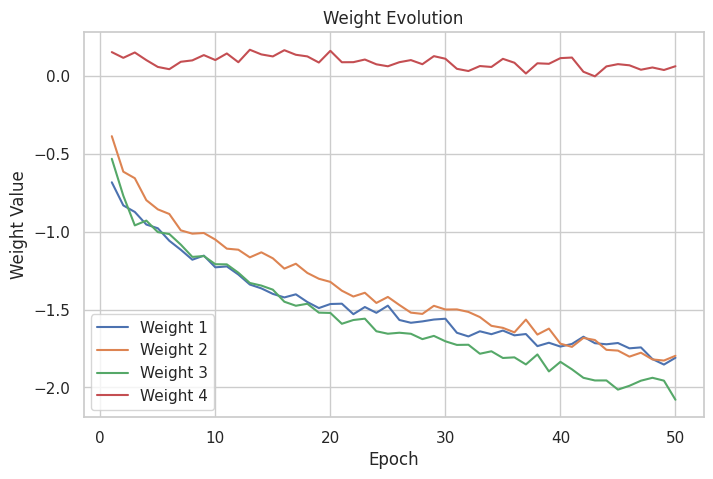

In [ ]:
weights = np.array(perceptron.weights_history)
plt.figure(figsize=(8,5))
for i in range(weights.shape[1]):
    plt.plot(range(1, len(weights)+1), weights[:, i], label=f'Weight {i+1}')
plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
plt.savefig('weight_evolution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

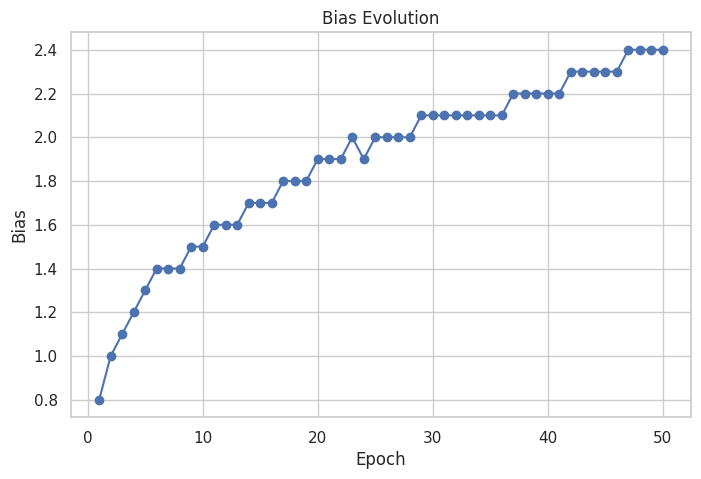

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(perceptron.bias_history)+1), perceptron.bias_history, marker='o')
plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.grid(True)
plt.savefig('bias_evolution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

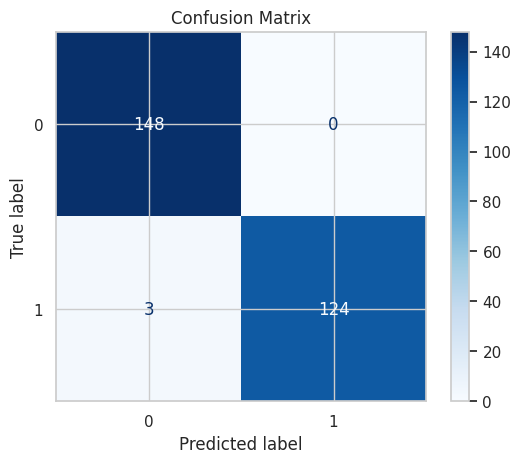

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_predictions(y_test, perceptron.predict(X_test), cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig('confusion_matrix.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
all_errors = {}

for lr in learning_rates:

    perceptron = Perceptron(learning_rate=lr)
    perceptron.fit(X_train, y_train)

    all_errors[lr] = perceptron.errors_history


Epoch 1
Misclassified Samples : 166
Weights : [-0.00682741 -0.00386685 -0.0053191   0.00152935]
Bias : 0.008

Epoch 2
Misclassified Samples : 88
Weights : [-0.00831161 -0.00614632 -0.00768784  0.00116242]
Bias : 0.010000000000000002

Epoch 3
Misclassified Samples : 57
Weights : [-0.00873157 -0.00656554 -0.00959305  0.001506  ]
Bias : 0.011000000000000003

Epoch 4
Misclassified Samples : 51
Weights : [-0.00953857 -0.00797431 -0.0092854   0.00101702]
Bias : 0.012000000000000004

Epoch 5
Misclassified Samples : 47
Weights : [-0.00977834 -0.00856403 -0.01002551  0.00057811]
Bias : 0.013000000000000005

Epoch 6
Misclassified Samples : 45
Weights : [-0.01058116 -0.00886184 -0.01014938  0.00043303]
Bias : 0.014000000000000005

Epoch 7
Misclassified Samples : 48
Weights : [-0.01116004 -0.00991264 -0.01083002  0.00090912]
Bias : 0.014000000000000005

Epoch 8
Misclassified Samples : 32
Weights : [-0.0117965  -0.01012441 -0.011616    0.00099908]
Bias : 0.014000000000000005

Epoch 9
Misclassified

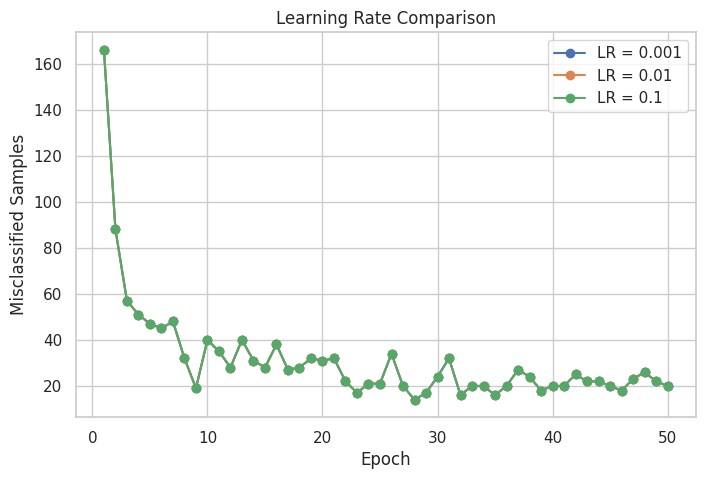

In [ ]:
plt.figure(figsize=(8,5))
for lr, errors in all_errors.items():
    plt.plot(range(1, len(errors)+1), errors, marker='o', label=f'LR = {lr}')
plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.legend()
plt.grid(True)
plt.savefig('learning_rate_comparison.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

# Select features for visualization
X_vis = X_scaled[:, :2]
y_vis = y.values

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y_vis, test_size=0.2, random_state=42)

# FIXED: Use eta0 instead of learning_rate for sklearn Perceptron
perceptron_vis = Perceptron(eta0=0.01, random_state=42)
perceptron_vis.fit(X_train_vis, y_train_vis)

x_min, x_max = X_vis[:,0].min()-0.1, X_vis[:,0].max()+0.1
y_min, y_max = X_vis[:,1].min()-0.1, X_vis[:,1].max()+0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = perceptron_vis.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_vis[:,0], X_vis[:,1], c=y_vis, cmap='coolwarm', edgecolors='k')
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Decision Boundary using Variance and Skewness")

# Saving for LaTeX report
plt.savefig('decision_boundary.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

TypeError: Perceptron.__init__() got an unexpected keyword argument 'learning_rate'

In [ ]:
# ============================================
# Scikit-learn PerceptronMetric Value
Dataset Size 1372 Samples
Train/Test Split 80% Training / 20% Testing (1097 / 275)
Learning Rate 0.01 (Best Performing Learning Rate)
Epochs 50 (Best Training Error at Epoch 28: 14
Misclassified Samples)
Final Weights [-0.1809, -0.1796, -0.2079,
# ============================================

from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Create model
sk_perceptron = Perceptron(
    eta0=0.01,
    max_iter=50,
    random_state=42,
    tol=None
)

# Train
sk_perceptron.fit(X_train, y_train)

# Predict
y_pred = sk_perceptron.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Scikit-learn Perceptron Performance")
print("-----------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nWeights:")
print(sk_perceptron.coef_)

print("\nBias:")
print(sk_perceptron.intercept_)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Scikit-learn Perceptron Performance
-----------------------------------
Accuracy : 0.9854545454545455
Precision: 1.0
Recall   : 0.968503937007874
F1-score : 0.984

Weights:
[[-0.18836504 -0.18495989 -0.19911608  0.00766793]]

Bias:
[0.24]

Confusion Matrix
[[148   0]
 [  4 123]]


In [ ]:
import pandas as pd

# Extracting history from the last trained perceptron instance
# Note: perceptron.weights_history stores a list of numpy arrays for each epoch

epoch_history = pd.DataFrame({
    'Epoch': range(1, len(perceptron.errors_history) + 1),
    'Misclassified Samples (Error)': perceptron.errors_history,
    'Weights': [list(np.round(w, 4)) for w in perceptron.weights_history],
    'Bias': np.round(perceptron.bias_history, 4)
})

print("Model Training Progression per Epoch")
display(epoch_history)

Model Training Progression per Epoch


,Epoch,Misclassified Samples (Error),Weights,Bias
0,1,166,"[-0.6827, -0.3867, -0.5319, 0.1529]",0.8
1,2,88,"[-0.8312, -0.6146, -0.7688, 0.1162]",1.0
2,3,57,"[-0.8732, -0.6566, -0.9593, 0.1506]",1.1
3,4,51,"[-0.9539, -0.7974, -0.9285, 0.1017]",1.2
4,5,47,"[-0.9778, -0.8564, -1.0026, 0.0578]",1.3
5,6,45,"[-1.0581, -0.8862, -1.0149, 0.0433]",1.4
6,7,48,"[-1.116, -0.9913, -1.083, 0.0909]",1.4
7,8,32,"[-1.1796, -1.0124, -1.1616, 0.0999]",1.4
8,9,19,"[-1.1535, -1.0082, -1.1563, 0.1338]",1.5
9,10,40,"[-1.2286, -1.0505, -1.2086, 0.1021]",1.5


In [ ]:
!ls *.eps

bias_evolution.eps	 learning_rate_comparison.eps
confusion_matrix.eps	 scatter_plot.eps
correlation_heatmap.eps  training_error_vs_epoch.eps
feature_histograms.eps	 weight_evolution.eps
